<a href="https://colab.research.google.com/github/Harveyt47/gdp-dashboard/blob/main/dsge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.mlemodel import MLEModel

class PiStarStateSpace(MLEModel):
    """
    State vector: [cpistar_t, cpistarL1_t]'
    Obs vector: [DL4PTM, GBUSEXP, GUNIEXPY, GUNIEXPYY, GMAREXPY, GMAREXPYY, GBONYLD]'
    The model accepts exog columns:
      - "DL4PTM_lag"  (for the delta * DL4PTM(-1) term)
      - dummy columns: "d_GBUSEXP", "d_GUNIEXPY", "d_GUNIEXPYY", "d_GMAREXPY", "d_GMAREXPYY"
      - optional constant columns for theta intercepts (or we treat theta as parameters)
    Parameters vector (params) will be ordered as:
      [delta, theta1..theta6, lambda1..lambda5, sigma1..sigma7, sigma8]
    """
    def __init__(self, endog, exog=None, initial_state=None, initial_cov=None, **kwargs):
        # endog: DataFrame with 7 columns in the specified order
        exog = None if exog is None else np.asarray(exog)
        k_states = 2
        super().__init__(endog, k_states=k_states, exog=exog, **kwargs)

        # Fixed transition matrix T (2x2)
        self['transition'] = np.array([[1., 0.],
                                       [1., 0.]])
        # Selection matrix: map state disturbances to states
        # We'll let only cpistar have a state shock (index 0)
        self['selection'] = np.eye(k_states)
        # Initialize other matrices in update()
        # Set initial state and covariance if supplied
        if initial_state is not None:
            self.initialize_approximate_diffuse()  # placeholder
            self.ssm.initial_state = np.asarray(initial_state).reshape(k_states)
            if initial_cov is not None:
                self.ssm.initial_state_cov = np.asarray(initial_cov)
        else:
            self.initialize_approximate_diffuse()

    def update(self, params, **kwargs):
        # params vector ordering as above
        # Unpack params
        # Ensure length is correct
        # params order chosen: delta, theta1..theta6, lambda1..lambda5, sigma1..sigma8
        delta = params[0]
        theta = params[1:7]        # 6 thetas
        lam = params[7:12]         # 5 lambdas
        sigma = params[12:20]      # 8 sigma values

        # Build observation matrix Z (7 x 2)
        Z = np.zeros((7,2))
        Z[:,0] = 1.0      # all obs load 1 on cpistar
        Z[0,1] = -delta   # DL4PTM row loads -delta on lag state
        # other rows have zero loading on cpistarL1 already

        self['design'] = Z

        # Observation covariance R (7x7)
        R = np.diag(sigma[:7]**2)
        self['obs_cov'] = R

        # State covariance Q (2x2)
        Q = np.zeros((2,2))
        Q[0,0] = sigma[7]**2   # cpistar shock variance
        Q[1,1] = 0.0
        self['state_cov'] = Q

        # Compose the deterministic exog effect d_t into the observation intercepts.
        # statsmodels supports time-varying observation intercept via 'obs_intercept'
        # We'll form obs_intercept[t] = [ delta*DL4PTM_lag_t, theta1 + lambda1*d_GBUSEXP_t, ... ]
        if self.exog is None:
            # No exog -> obs intercept is zeros
            self['obs_intercept'] = np.zeros((len(self.endog), 1))
        else:
            # Build obs_intercept over time (T x k_obs) and assign to ssm.obs_intercept (time-varying)
            Tobs = self.endog.shape[0]
            obs_intercept = np.zeros((7, Tobs))
            # Extract exog columns in expected order (caller must supply them)
            ex = np.asarray(self.exog)
            # assume ex columns: [DL4PTM_lag, d_GBUSEXP, d_GUNIEXPY, d_GUNIEXPYY, d_GMAREXPY, d_GMAREXPYY]
            dl_lag = ex[:,0]
            d_gbusexp, d_guniexpy, d_guniexpyy, d_gmarexpy, d_gmarexpyy = ex[:,1:6].T

            # DL4PTM intercept: delta * DL4PTM_lag
            obs_intercept[0, :] = delta * dl_lag
            # For the other rows, we include theta + lambda*dummy
            obs_intercept[1, :] = theta[0] + lam[0]*d_gbusexp
            obs_intercept[2, :] = theta[1] + lam[1]*d_guniexpy
            obs_intercept[3, :] = theta[2] + lam[2]*d_guniexpyy
            obs_intercept[4, :] = theta[3] + lam[3]*d_gmarexpy
            obs_intercept[5, :] = theta[4] + lam[4]*d_gmarexpyy
            obs_intercept[6, :] = theta[5]   # GBONYLD has only theta

            self.ssm.obs_intercept = obs_intercept
    @property
    def start_params(self):
        # sensible starting parameters (length 20)
        # delta, theta1..6, lambda1..5, sigma1..sigma8
        start = np.r_[0.2, np.zeros(6), np.zeros(5), np.ones(8)*0.1]
        return start



/tmp/ipython-input-801411375.py:51: ComplexWarning: Casting complex values to real discards the imaginary part
  Z[0,1] = -delta   # DL4PTM row loads -delta on lag state
/tmp/ipython-input-801411375.py:62: ComplexWarning: Casting complex values to real discards the imaginary part
  Q[0,0] = sigma[7]**2   # cpistar shock variance
/tmp/ipython-input-801411375.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  obs_intercept[0, :] = delta * dl_lag
/tmp/ipython-input-801411375.py:85: ComplexWarning: Casting complex values to real discards the imaginary part
  obs_intercept[1, :] = theta[0] + lam[0]*d_gbusexp
/tmp/ipython-input-801411375.py:86: ComplexWarning: Casting complex values to real discards the imaginary part
  obs_intercept[2, :] = theta[1] + lam[1]*d_guniexpy
/tmp/ipython-input-801411375.py:87: ComplexWarning: Casting complex values to real discards the imaginary part
  obs_intercept[3, :] = theta[2] + lam[2]*d_guniexpyy
/tmp/ipython-input-80141137

                                                           Statespace Model Results                                                           
Dep. Variable:     ['DL4PTM', 'GBUSEXP', 'GUNIEXPY', 'GUNIEXPYY', 'GMAREXPY', 'GMAREXPYY', 'GBONYLD']   No. Observations:                  120
Model:                                                                               PiStarStateSpace   Log Likelihood                 104.960
Date:                                                                                Mon, 08 Dec 2025   AIC                           -169.919
Time:                                                                                        08:42:28   BIC                           -114.169
Sample:                                                                                             0   HQIC                          -147.279
                                                                                                - 120                                         

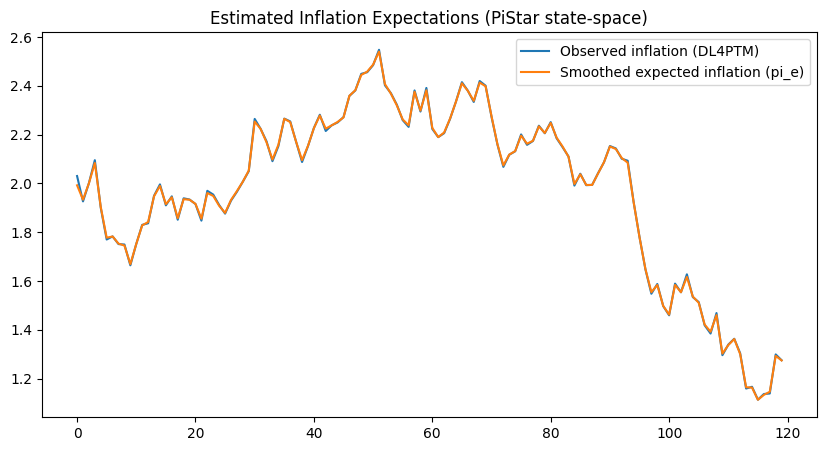

In [ ]:
import numpy as np
import pandas as pd

# Assume PiStarStateSpace class has been defined (as shown before)

# Step 1: create fake data
T = 120
rng = np.random.default_rng(42)

# fake inflation (DL4PTM) process
DL4PTM = 2 + np.cumsum(rng.normal(0, 0.1, T))  # trending around 2%
DL4PTM_lag = np.r_[np.nan, DL4PTM[:-1]]

# fake surveys that loosely follow cpistar + noise
GBUSEXP = DL4PTM + rng.normal(0, 0.2, T)
GUNIEXPY = DL4PTM + rng.normal(0, 0.3, T)
GUNIEXPYY = DL4PTM + rng.normal(0, 0.3, T)
GMAREXPY = DL4PTM + rng.normal(0, 0.25, T)
GMAREXPYY = DL4PTM + rng.normal(0, 0.25, T)
GBONYLD = DL4PTM + rng.normal(0, 0.2, T)

# dummies (just zeros except a small block around t=40)
d_GBUSEXP = np.zeros(T); d_GBUSEXP[40:42] = 1
d_GUNIEXPY = np.zeros(T); d_GUNIEXPY[38:44] = 1
d_GUNIEXPYY = np.zeros(T); d_GUNIEXPYY[38:44] = 1
d_GMAREXPY = np.zeros(T); d_GMAREXPY[40:42] = 1
d_GMAREXPYY = np.zeros(T); d_GMAREXPYY[40:42] = 1

# Step 2: assemble DataFrames
endog = pd.DataFrame({
    "DL4PTM": DL4PTM,
    "GBUSEXP": GBUSEXP,
    "GUNIEXPY": GUNIEXPY,
    "GUNIEXPYY": GUNIEXPYY,
    "GMAREXPY": GMAREXPY,
    "GMAREXPYY": GMAREXPYY,
    "GBONYLD": GBONYLD,
})

exog = pd.DataFrame({
    "DL4PTM_lag": DL4PTM_lag,
    "d_GBUSEXP": d_GBUSEXP,
    "d_GUNIEXPY": d_GUNIEXPY,
    "d_GUNIEXPYY": d_GUNIEXPYY,
    "d_GMAREXPY": d_GMAREXPY,
    "d_GMAREXPYY": d_GMAREXPYY,
}).fillna(0)

# Step 3: instantiate and fit
model = PiStarStateSpace(endog, exog=exog)
res = model.fit(disp=False)

# Step 4: extract smoothed state (pi_e)
smoothed = res.smoothed_state
pi_e = smoothed[0]
pi_e_lag = smoothed[1]

# Step 5: attach to DataFrame and inspect
df = endog.copy()
df["pi_e"] = pi_e
df["pi_e_lag"] = pi_e_lag

print(res.summary())
print(df.head())

# Optional: plot smoothed cpistar
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df["DL4PTM"], label="Observed inflation (DL4PTM)")
plt.plot(df["pi_e"], label="Smoothed expected inflation (pi_e)")
plt.legend()
plt.title("Estimated Inflation Expectations (PiStar state-space)")
plt.show()

In [ ]:
print(res.summary())

                                                           Statespace Model Results                                                           
Dep. Variable:     ['DL4PTM', 'GBUSEXP', 'GUNIEXPY', 'GUNIEXPYY', 'GMAREXPY', 'GMAREXPYY', 'GBONYLD']   No. Observations:                  120
Model:                                                                               PiStarStateSpace   Log Likelihood                 104.960
Date:                                                                                Mon, 08 Dec 2025   AIC                           -169.919
Time:                                                                                        08:42:29   BIC                           -114.169
Sample:                                                                                             0   HQIC                          -147.279
                                                                                                - 120                                         

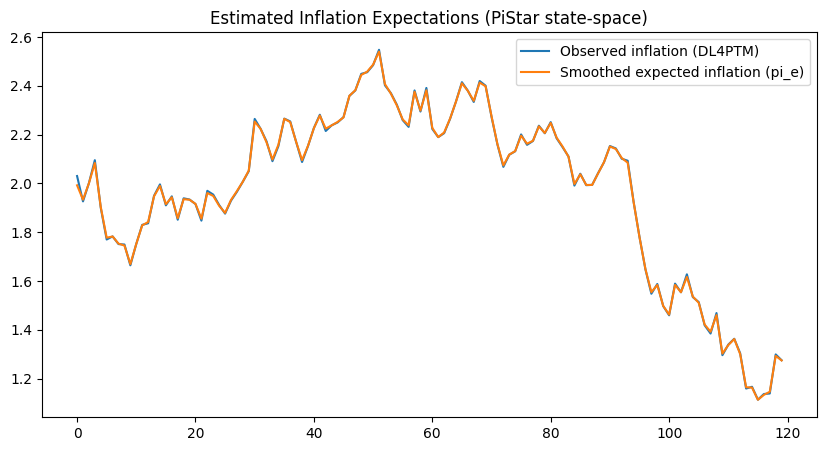

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df["DL4PTM"], label="Observed inflation (DL4PTM)")
plt.plot(df["pi_e"], label="Smoothed expected inflation (pi_e)")
plt.legend()
plt.title("Estimated Inflation Expectations (PiStar state-space)")
plt.show()


In [ ]:
class NAIRUStateSpace(MLEModel):
    """
    Two-observation SS model estimating NAIRU (state dim = 1).
    endog: DataFrame with columns ['dlptm','dlulc']
    exog: DataFrame with columns
      ['pi_eq','dlptm_lag1','dlptm_lag2','dlptm_lag3',
       'dlulc_lag1','dlulc_lag2','dLUR_lag1_div_LUR','dl4pimp_lag1','LUR']
    params ordering:
      [delta1, delta2,
       beta1,beta2,beta3,    # dlptm lags
       omega1,omega2,        # dlulc lags
       phi, alpha,
       gamma1,gamma2,
       lambda1,lambda2,
       log_sigma1, log_sigma2, log_sigma3]  # LOG of standard deviations
    """
    def __init__(self, endog, exog, initial_state=None, initial_cov=None, **kwargs):
        super().__init__(endog, k_states=1, exog=exog, **kwargs)
        self['transition'] = np.array([[1.0]])
        self['selection'] = np.array([[1.0]])
        self.exog_df = exog

        # Initialize NAIRU at the mean of LUR
        if initial_state is None:
            initial_state = np.array([exog['LUR'].mean()])
        if initial_cov is None:
            initial_cov = np.array([[1.0]])

        self.initialize_known(initial_state, initial_cov)

    def update(self, params, **kwargs):
        p = np.asarray(params)

        # Unpack structural parameters
        delta1, delta2 = p[0], p[1]
        beta1, beta2, beta3 = p[2:5]
        omega1, omega2 = p[5:7]
        phi = p[7]
        alpha = p[8]
        gamma1, gamma2 = p[9], p[10]
        lambda1, lambda2 = p[11], p[12]

        # Transform log sigmas to actual sigmas with clipping for numerical stability
        log_sigma1, log_sigma2, log_sigma3 = p[13], p[14], p[15]
        sigma1 = np.exp(np.clip(log_sigma1, -10, 3))  # sigma1 in [0.00005, 20]
        sigma2 = np.exp(np.clip(log_sigma2, -10, 3))  # sigma2 in [0.00005, 20]
        sigma3 = np.exp(np.clip(log_sigma3, -10, -1)) # sigma3 in [0.00005, 0.37] - force smoothness!

        T = len(self.endog)
        exog = self.exog_df
        LUR = np.asarray(self.exog_df['LUR']).astype(float)

        # Avoid division by zero
        LUR = np.clip(LUR, 0.1, 100.0)
        invLUR = 1.0 / LUR

        # Design matrix Z: (k_endog, k_states, T)
        Z = np.zeros((2, 1, T))
        Z[0, 0, :] = -gamma1 * invLUR
        Z[1, 0, :] = -gamma2 * invLUR
        self.ssm.design = Z

        # Observation intercept: (k_endog, T)
        obs_intercept = np.zeros((2, T))

        obs_intercept[0,:] = (
            delta1 * np.asarray(exog['pi_eq']) +
            beta1 * np.asarray(exog['dlptm_lag1']) +
            beta2 * np.asarray(exog['dlptm_lag2']) +
            beta3 * np.asarray(exog['dlptm_lag3']) +
            phi * np.asarray(exog['dlulc_lag1']) +
            lambda1 * np.asarray(exog['dLUR_lag1_div_LUR']) +
            alpha * np.asarray(exog['dl4pimp_lag1']) +
            gamma1
        )

        obs_intercept[1,:] = (
            delta2 * np.asarray(exog['pi_eq']) +
            omega1 * np.asarray(exog['dlulc_lag1']) +
            omega2 * np.asarray(exog['dlulc_lag2']) +
            lambda2 * np.asarray(exog['dLUR_lag1_div_LUR']) +
            gamma2
        )


        self.ssm.obs_intercept = obs_intercept

        # Observation covariance R (2x2)
        R = np.zeros((2, 2))
        R[0, 0] = sigma1**2
        R[1, 1] = sigma2**2
        self['obs_cov'] = R

        # State covariance Q (1x1)
        Q = np.array([[sigma3**2]])
        self['state_cov'] = Q

    @property
    def start_params(self):
        """Starting values - sigmas are in LOG space"""
        return np.array([
            0.5, 0.5,          # delta1, delta2
            0.3, 0.2, 0.1,     # beta1-3
            0.3, 0.2,          # omega1-2
            0.1, 0.05,         # phi, alpha
            0.3, 0.3,          # gamma1, gamma2
            0.05, 0.05,        # lambda1, lambda2
            np.log(0.3),       # log(sigma1)
            np.log(0.3),       # log(sigma2)
            np.log(0.03)       # log(sigma3) - small for smooth NAIRU
        ])

    @property
    def param_names(self):
        """Parameter names for output"""
        return ['delta1', 'delta2',
                'beta1', 'beta2', 'beta3',
                'omega1', 'omega2',
                'phi', 'alpha',
                'gamma1', 'gamma2',
                'lambda1', 'lambda2',
                'log_sigma1', 'log_sigma2', 'log_sigma3']


In [ ]:
def generate_nairu_test_data(T=160, seed=42):
    """Generate synthetic data that MATCHES the model specification"""
    rng = np.random.default_rng(seed)
    quarters = pd.period_range("1986Q3", periods=T, freq="Q")

    # TRUE NAIRU: random walk around 5.5%
    nairu_true = np.zeros(T)
    nairu_true[0] = 5.5
    for t in range(1, T):
        nairu_true[t] = nairu_true[t-1] + rng.normal(0, 0.03)  # Smaller drift
    nairu_true = np.clip(nairu_true, 4.0, 7.0)

    # Unemployment rate cycles around NAIRU
    ygap = 2*np.sin(np.linspace(0, 6*np.pi, T)) + rng.normal(0, 0.5, T)
    LUR = nairu_true - 0.4*ygap + rng.normal(0, 0.3, T)
    LUR = np.clip(LUR, 3.0, 9.0)

    # Inflation expectations
    pi_eq = 2.5 + 0.3*np.sin(np.linspace(0, 4*np.pi, T)) + rng.normal(0, 0.1, T)

    # TRUE PARAMETERS (what we'll try to recover)
    delta1_true, delta2_true = 0.5, 0.5
    beta1_true, beta2_true, beta3_true = 0.3, 0.2, 0.1
    omega1_true, omega2_true = 0.3, 0.2
    phi_true, alpha_true = 0.1, 0.05
    gamma1_true, gamma2_true = 0.5, 0.3  # POSITIVE coefficients
    lambda1_true, lambda2_true = 0.05, 0.05
    sigma1_true, sigma2_true = 0.3, 0.3

    # Generate endogenous variables following the MODEL'S structure
    dlptm = np.zeros(T)
    dlulc = np.zeros(T)
    dl4pimp = pi_eq + rng.normal(0, 0.5, T)

    for t in range(T):
        # Lags
        dlptm_l1 = dlptm[t-1] if t > 0 else 0
        dlptm_l2 = dlptm[t-2] if t > 1 else 0
        dlptm_l3 = dlptm[t-3] if t > 2 else 0
        dlulc_l1 = dlulc[t-1] if t > 0 else 0
        dlulc_l2 = dlulc[t-2] if t > 1 else 0
        dl4pimp_l1 = dl4pimp[t-1] if t > 0 else 0

        # dLUR/LUR term
        LUR_l1 = LUR[t-1] if t > 0 else LUR[0]
        dLUR_l1 = LUR_l1 - (LUR[t-2] if t > 1 else LUR[0])
        dLUR_l1_div_LUR = dLUR_l1 / LUR[t]

        # INFLATION EQUATION (matching your state-space specification):
        # dlptm = delta1*pi_eq + beta*lags + phi*dlulc_lag + lambda*dLUR + alpha*import
        #         + gamma1 - (gamma1/LUR)*NAIRU + error
        dlptm[t] = (
            delta1_true * pi_eq[t] +
            beta1_true * dlptm_l1 + beta2_true * dlptm_l2 + beta3_true * dlptm_l3 +
            phi_true * dlulc_l1 +
            lambda1_true * dLUR_l1_div_LUR +
            alpha_true * dl4pimp_l1 +
            gamma1_true * (1.0 - nairu_true[t]/LUR[t]) +  # KEY: gamma*(LUR-NAIRU)/LUR
            rng.normal(0, sigma1_true)
        )

        # WAGE EQUATION:
        # dlulc = delta2*pi_eq + omega*lags + lambda*dLUR
        #         + gamma2 - (gamma2/LUR)*NAIRU + error
        dlulc[t] = (
            delta2_true * pi_eq[t] +
            omega1_true * dlulc_l1 + omega2_true * dlulc_l2 +
            lambda2_true * dLUR_l1_div_LUR +
            gamma2_true * (1.0 - nairu_true[t]/LUR[t]) +  # KEY: gamma*(LUR-NAIRU)/LUR
            rng.normal(0, sigma2_true)
        )

    # Create proper lags for estimation
    def lag(x, k=1):
        return np.r_[np.full(k, x[0]), x[:-k]]

    dlptm_lag1, dlptm_lag2, dlptm_lag3 = lag(dlptm,1), lag(dlptm,2), lag(dlptm,3)
    dlulc_lag1, dlulc_lag2 = lag(dlulc,1), lag(dlulc,2)
    dl4pimp_lag1 = lag(dl4pimp,1)
    LUR_lag1 = lag(LUR, 1)
    dLUR_lag1 = np.r_[0, np.diff(LUR_lag1)]
    dLUR_lag1_div_LUR = dLUR_lag1 / LUR

    endog_df = pd.DataFrame({
        "dlptm": dlptm,
        "dlulc": dlulc,
    }, index=quarters.to_timestamp())

    exog_df = pd.DataFrame({
        "pi_eq": pi_eq,
        "dlptm_lag1": dlptm_lag1,
        "dlptm_lag2": dlptm_lag2,
        "dlptm_lag3": dlptm_lag3,
        "dlulc_lag1": dlulc_lag1,
        "dlulc_lag2": dlulc_lag2,
        "dLUR_lag1_div_LUR": dLUR_lag1_div_LUR,
        "dl4pimp_lag1": dl4pimp_lag1,
        "LUR": LUR,
        "nairu_true": nairu_true,
    }, index=quarters.to_timestamp())

    return endog_df, exog_df

In [ ]:
# Generate test data
endog_df, exog_df = generate_nairu_test_data(T=160, seed=42)

# Create and fit model
model = NAIRUStateSpace(endog_df, exog_df)

# Fit with L-BFGS-B optimizer
res = model.fit(
  method='lbfgs',
  maxiter=1000,
  disp=True
)

# Print results
print("\n" + "="*60)
print("NAIRU State-Space Model - Parameter Estimates")
print("="*60)
print(f"{'Parameter':<20} {'Estimate':>12} {'Std Error':>12}")
print("-"*60)
print(f"{'delta1 (infl exp)':<20} {res.params[0]:>12.4f}")
print(f"{'delta2 (wage exp)':<20} {res.params[1]:>12.4f}")
print(f"{'beta1 (AR1)':<20} {res.params[2]:>12.4f}")
print(f"{'beta2 (AR2)':<20} {res.params[3]:>12.4f}")
print(f"{'beta3 (AR3)':<20} {res.params[4]:>12.4f}")
print(f"{'omega1 (wage AR1)':<20} {res.params[5]:>12.4f}")
print(f"{'omega2 (wage AR2)':<20} {res.params[6]:>12.4f}")
print(f"{'phi (spillover)':<20} {res.params[7]:>12.4f}")
print(f"{'alpha (import)':<20} {res.params[8]:>12.4f}")
print(f"{'gamma1 (Okun-infl)':<20} {res.params[9]:>12.4f}")
print(f"{'gamma2 (Okun-wage)':<20} {res.params[10]:>12.4f}")
print(f"{'lambda1 (LUR dyn)':<20} {res.params[11]:>12.4f}")
print(f"{'lambda2 (LUR dyn)':<20} {res.params[12]:>12.4f}")
print(f"{'sigma1 (infl err)':<20} {res.params[13]:>12.4f}")
print(f"{'sigma2 (wage err)':<20} {res.params[14]:>12.4f}")
print(f"{'sigma3 (state)':<20} {res.params[15]:>12.4f}")
print("="*60)
print(f"Log-likelihood: {res.llf:.2f}")
print(f"AIC: {res.aic:.2f}")
print(f"BIC: {res.bic:.2f}")


NAIRU State-Space Model - Parameter Estimates
Parameter                Estimate    Std Error
------------------------------------------------------------
delta1 (infl exp)          0.3243
delta2 (wage exp)          0.4275
beta1 (AR1)                0.4510
beta2 (AR2)                0.0607
beta3 (AR3)                0.1678
omega1 (wage AR1)          0.3576
omega2 (wage AR2)          0.2082
phi (spillover)            0.2050
alpha (import)            -0.0032
gamma1 (Okun-infl)         0.1637
gamma2 (Okun-wage)         0.1418
lambda1 (LUR dyn)         -0.2845
lambda2 (LUR dyn)          0.0939
sigma1 (infl err)         -1.1862
sigma2 (wage err)         -1.2594
sigma3 (state)            -3.4948
Log-likelihood: -63.18
AIC: 158.36
BIC: 207.56


/tmp/ipython-input-1143653307.py:59: ComplexWarning: Casting complex values to real discards the imaginary part
  Z[0, 0, :] = -gamma1 * invLUR
/tmp/ipython-input-1143653307.py:60: ComplexWarning: Casting complex values to real discards the imaginary part
  Z[1, 0, :] = -gamma2 * invLUR
/tmp/ipython-input-1143653307.py:66: ComplexWarning: Casting complex values to real discards the imaginary part
  obs_intercept[0,:] = (
/tmp/ipython-input-1143653307.py:77: ComplexWarning: Casting complex values to real discards the imaginary part
  obs_intercept[1,:] = (
/tmp/ipython-input-1143653307.py:90: ComplexWarning: Casting complex values to real discards the imaginary part
  R[0, 0] = sigma1**2
/tmp/ipython-input-1143653307.py:91: ComplexWarning: Casting complex values to real discards the imaginary part
  R[1, 1] = sigma2**2
/tmp/ipython-input-1529410853.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated 

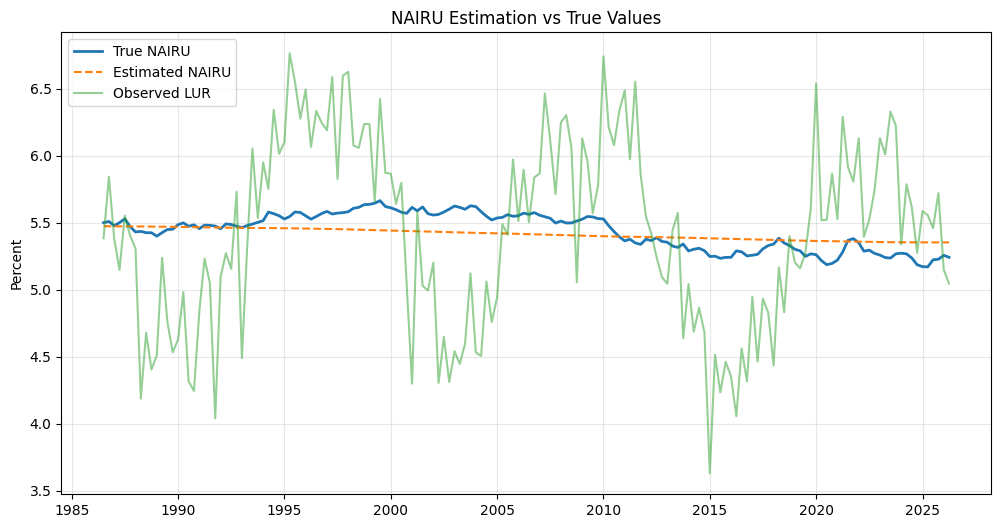

In [ ]:

# Plot results
smoothed_nairu = res.smoothed_state[0]
plt.figure(figsize=(12, 6))
plt.plot(exog_df.index, exog_df['nairu_true'], label='True NAIRU', linewidth=2)
plt.plot(exog_df.index, smoothed_nairu, label='Estimated NAIRU', linestyle='--')
plt.plot(exog_df.index, exog_df['LUR'], label='Observed LUR', alpha=0.5)
plt.legend()
plt.ylabel('Percent')
plt.title('NAIRU Estimation vs True Values')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# After fitting, check if estimated gammas are reasonable
print("\nKey parameters for NAIRU identification:")
print(f"gamma1 (Okun-inflation): {res.params[9]:.4f}")
print(f"gamma2 (Okun-wage): {res.params[10]:.4f}")
print(f"Actual sigma3 (state drift): {np.exp(res.params[15]):.4f}")

# These gammas should be positive (higher NAIRU -> lower inflation)
# If gamma1 ≈ 0, the model can't identify NAIRU from inflation data


Key parameters for NAIRU identification:
gamma1 (Okun-inflation): 0.1637
gamma2 (Okun-wage): 0.1418
Actual sigma3 (state drift): 0.0304


/tmp/ipython-input-1767780929.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"gamma1 (Okun-inflation): {res.params[9]:.4f}")
/tmp/ipython-input-1767780929.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"gamma2 (Okun-wage): {res.params[10]:.4f}")
/tmp/ipython-input-1767780929.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Actual sigma3 (state drift): {np.exp(res.params[15]):.4f}")


In [ ]:
class RStarStateSpace(MLEModel):
    """
    State-space model for neutral rate (nrate / rstar) estimation.

    States (11):
      [ygap, ygapL1, ygapL2, ygapL3, ypot, g, NAIRU, NAIRUL1, nrate, nrateL1, z]

    Observations (3):
      ['lrgdp', 'LUR', 'dlptm']

    Exog columns expected:
      ['pi_eq', 'dlptm_lag1', 'dlptm_lag2', 'dlptm_lag3',
       'rcash_lag1', 'rcash_lag2', 'LUR']

    Parameters (16):
      [delta1, delta2, delta3,           # Not used in estimation (for initial conditions)
       alpha1, alpha2, alpha3,            # IS curve parameters
       beta1,                             # Okun's law
       gamma1, gamma2,                    # Phillips curve
       sigma1, sigma2, sigma3, sigma4, sigma5, sigma6, sigma7]  # Variances

    Shocks:
      - 5 state shocks: e1(ygap), e4(NAIRU), e5(ypot), e6(z), e7(g)
      - 2 observation errors: e2(LUR), e3(dlptm)
    """

    def __init__(self, endog, exog, initial_state=None, initial_cov=None, **kwargs):
        self.exog_df = exog.copy()



        super().__init__(endog, k_states=11, exog=np.asarray(exog), **kwargs)

        # Base transition matrix (will be updated in update())
        T0 = np.zeros((11, 11))
        # Lag chains
        T0[1, 0] = 1.0  # ygapL1 = ygap(-1)
        T0[2, 1] = 1.0  # ygapL2 = ygapL1(-1)
        T0[3, 2] = 1.0  # ygapL3 = ygapL2(-1)
        T0[7, 6] = 1.0  # NAIRUL1 = NAIRU(-1)
        T0[9, 8] = 1.0  # nrateL1 = nrate(-1)
        # Random walks
        T0[4, 4] = 1.0  # ypot = ypot(-1) + g(-1) (g added in update)
        T0[5, 5] = 1.0  # g = g(-1)
        T0[6, 6] = 1.0  # NAIRU = NAIRU(-1)
        T0[10, 10] = 1.0  # z = z(-1)
        self['transition'] = T0

        # Selection matrix: (k_states, k_states) = (11, 11)
        # This is an identity-like matrix showing which states have shocks
        # Non-standard: nrate gets shocks from BOTH g and z
        R = np.eye(11)
        # Most states have unit shock (identity)
        # But nrate is special: it gets 4*e7 + 1*e6
        # We handle this by adjusting the selection matrix
        R[8, 8] = 0.0   # nrate doesn't have its own shock
        R[8, 5] = 4.0   # nrate gets 4 * shock to g (e7)
        R[8, 10] = 1.0  # nrate gets 1 * shock to z (e6)
        self['selection'] = R

        # State labels
        self.ssm._state_names = [
            "ygap", "ygapL1", "ygapL2", "ygapL3",
            "ypot", "g", "NAIRU", "NAIRUL1",
            "nrate", "nrateL1", "z"
        ]

        # Initialize state using HP filter estimates (like EViews)
        if initial_state is None:
            from statsmodels.tsa.filters.hp_filter import hpfilter

            # HP filter to get initial estimates
            lrgdp = endog['lrgdp'].values
            LUR = exog['LUR'].values

            # Get trend components
            _, ypot_ini = hpfilter(lrgdp, lamb=1600)
            _, nairu_ini = hpfilter(LUR, lamb=1600)

            # Initial output gap
            ygap_ini = lrgdp - ypot_ini

            # Initial growth rate (quarterly)
            g_ini = np.diff(ypot_ini, prepend=ypot_ini[0])

            # Initial neutral rate (rough estimate: 4 * trend growth + 2%)
            nrate_ini = 4 * g_ini + 2.0

            # Initial z (residual component)
            z_ini = nrate_ini - 4 * g_ini

            # Build initial state vector [ygap, ygapL1, ygapL2, ygapL3, ypot, g, NAIRU, NAIRUL1, nrate, nrateL1, z]
            initial_state = np.array([
                ygap_ini[0],      # ygap
                ygap_ini[0],      # ygapL1 (use same value initially)
                ygap_ini[0],      # ygapL2
                ygap_ini[0],      # ygapL3
                ypot_ini[0],      # ypot
                g_ini[0],         # g
                nairu_ini[0],     # NAIRU
                nairu_ini[0],     # NAIRUL1
                nrate_ini[0],     # nrate
                nrate_ini[0],     # nrateL1
                z_ini[0]          # z
            ])

            # Initial covariance (modest uncertainty)
            initial_cov = np.diag([
                0.5, 0.5, 0.5, 0.5,  # ygap and lags
                1.0,                  # ypot
                0.1,                  # g
                0.2, 0.2,            # NAIRU and lag
                0.5, 0.5,            # nrate and lag
                0.5                   # z
            ])

            self.initialize_known(initial_state, initial_cov)
        else:
            self.initialize_known(initial_state, initial_cov)

    def update(self, params, **kwargs):
        p = np.asarray(params)

        # Unpack parameters
        delta1, delta2, delta3 = p[0], p[1], p[2]  # Not used in estimation
        alpha1, alpha2, alpha3 = p[3], p[4], p[5]
        beta1 = p[6]
        gamma1, gamma2 = p[7], p[8]

        # Transform log sigmas to ensure positivity
        log_sigma = p[9:16]
        sigma = np.exp(np.clip(log_sigma, -10, 2))  # Force positive, bounded

        ex = self.exog_df
        T = len(self.endog)

        # ========== OBSERVATION EQUATIONS ==========

        # Design matrix Z: (k_endog=3, k_states=11, T)
        Z = np.zeros((3, 11, T))

        # Observation 1: lrgdp = ypot + ygap
        Z[0, 0, :] = 1.0   # ygap
        Z[0, 4, :] = 1.0   # ypot

        # Observation 2: LUR = NAIRU + beta1*(0.4*ygap + 0.3*ygapL1 + 0.2*ygapL2 + 0.1*ygapL3)
        Z[1, 6, :] = 1.0              # NAIRU
        Z[1, 0, :] = beta1 * 0.4      # ygap
        Z[1, 1, :] = beta1 * 0.3      # ygapL1
        Z[1, 2, :] = beta1 * 0.2      # ygapL2
        Z[1, 3, :] = beta1 * 0.1      # ygapL3

        # Observation 3: dlptm = (1-gamma1)*pi_eq + gamma1/3*(dlptm lags) + gamma2*(LUR(-1) - NAIRUL1)
        Z[2, 7, :] = -gamma2          # -gamma2 * NAIRUL1

        self.ssm.design = Z

        # Observation intercept: (k_endog=3, T)
        obs_intercept = np.zeros((3, T))

        # lrgdp: no intercept (identity)
        # LUR: no intercept (NAIRU + Okun's law)

        # dlptm intercept: (1-gamma1)*pi_eq + gamma1/3*(dlptm(-1)+dlptm(-2)+dlptm(-3)) + gamma2*LUR(-1)
        pi_eq = ex['pi_eq'].values
        dlptm_l1 = ex['dlptm_lag1'].values
        dlptm_l2 = ex['dlptm_lag2'].values
        dlptm_l3 = ex['dlptm_lag3'].values
        LUR = ex['LUR'].values

        # Use proper lagging instead of np.roll
        LUR_lag1 = np.r_[LUR[0], LUR[:-1]]  # LUR(-1)

        obs_intercept[2, :] = (
            (1.0 - gamma1) * pi_eq +
            (gamma1 / 3.0) * (dlptm_l1 + dlptm_l2 + dlptm_l3) +
            gamma2 * LUR_lag1
        )

        self.ssm.obs_intercept = obs_intercept

        # ========== STATE EQUATIONS ==========

        # Transition matrix T: (11, 11)
        Tmat = np.zeros((11, 11))

        # State 0: ygap = alpha1*ygap(-1) + alpha2*ygapL1(-1) - alpha3/2*(rcash-nrate lags)
        Tmat[0, 0] = alpha1           # ygap(-1)
        Tmat[0, 1] = alpha2           # ygapL1(-1)
        Tmat[0, 8] = alpha3 / 2       # nrate(-1)  [NOTE: positive because rcash term is negative]
        Tmat[0, 9] = alpha3 / 2       # nrateL1(-1)

        # States 1-3: Lag chains
        Tmat[1, 0] = 1.0  # ygapL1 = ygap(-1)
        Tmat[2, 1] = 1.0  # ygapL2 = ygapL1(-1)
        Tmat[3, 2] = 1.0  # ygapL3 = ygapL2(-1)

        # State 4: ypot = ypot(-1) + g(-1)
        Tmat[4, 4] = 1.0  # ypot(-1)
        Tmat[4, 5] = 1.0  # g(-1)

        # State 5: g = g(-1)
        Tmat[5, 5] = 1.0

        # State 6-7: NAIRU = NAIRU(-1), NAIRUL1 = NAIRU(-1)
        Tmat[6, 6] = 1.0
        Tmat[7, 6] = 1.0

        # State 8: nrate = 4*g(-1) + z(-1) [plus shocks via selection matrix]
        Tmat[8, 5] = 4.0   # 4 * g(-1)
        Tmat[8, 10] = 1.0  # z(-1)

        # State 9: nrateL1 = nrate(-1)
        Tmat[9, 8] = 1.0

        # State 10: z = z(-1)
        Tmat[10, 10] = 1.0

        self['transition'] = Tmat

        # State intercept (TIME-VARYING): (11, T)
        state_intercept = np.zeros((11, T))

        # Only ygap equation has time-varying intercept: -alpha3/2*(rcash(-1) + rcash(-2))
        rcash_lag1 = ex['rcash_lag1'].values
        rcash_lag2 = ex['rcash_lag2'].values
        state_intercept[0, :] = -alpha3 / 2 * (rcash_lag1 + rcash_lag2)

        self.ssm.state_intercept = state_intercept

        # ========== COVARIANCE MATRICES ==========

        # State covariance Q: (11, 11)
        # Diagonal elements correspond to variances of shocks to each state
        # States without shocks have zero variance
        Q = np.zeros((11, 11))
        Q[0, 0] = sigma[0]**2   # e1 → ygap
        Q[1, 1] = 0.0           # ygapL1 has no shock (deterministic lag)
        Q[2, 2] = 0.0           # ygapL2 has no shock (deterministic lag)
        Q[3, 3] = 0.0           # ygapL3 has no shock (deterministic lag)
        Q[4, 4] = sigma[4]**2   # e5 → ypot
        Q[5, 5] = sigma[6]**2   # e7 → g
        Q[6, 6] = sigma[3]**2   # e4 → NAIRU
        Q[7, 7] = 0.0           # NAIRUL1 has no shock (deterministic lag)
        Q[8, 8] = 0.0           # nrate gets shocks via selection from g and z
        Q[9, 9] = 0.0           # nrateL1 has no shock (deterministic lag)
        Q[10, 10] = sigma[5]**2 # e6 → z
        self['state_cov'] = Q

        # Observation covariance R: (3, 3)
        R_obs = np.zeros((3, 3))
        R_obs[0, 0] = 0.0           # lrgdp: NO observation error (identity)
        R_obs[1, 1] = sigma[1]**2   # LUR: e2 variance
        R_obs[2, 2] = sigma[2]**2   # dlptm: e3 variance
        self['obs_cov'] = R_obs

    @property
    def start_params(self):
        """Starting values for maximum likelihood estimation"""
        return np.array([
            0.0, 0.0, 0.0,           # delta1, delta2, delta3 (not used)
            0.6, 0.2, 0.05,          # alpha1, alpha2, alpha3
            0.5,                     # beta1
            0.3, 0.1,                # gamma1, gamma2
            np.log(0.2),             # log(sigma1) - ygap
            np.log(0.2),             # log(sigma2) - LUR obs
            np.log(0.2),             # log(sigma3) - dlptm obs
            np.log(0.1),            # log(sigma4) - NAIRU
            np.log(0.1),             # log(sigma5) - ypot
            np.log(0.05),            # log(sigma6) - z
            np.log(0.02)             # log(sigma7) - g
        ])

In [ ]:
def generate_rstar_test_data(T=160, seed=42):
    """
    Generate synthetic data that matches the R-Star model structure.
    CORRECTED VERSION with proper ygap cycles and scale.
    """
    np.random.seed(seed)
    dates = pd.period_range("1986Q3", periods=T, freq="Q")

    # TRUE PARAMETERS
    alpha1_true, alpha2_true, alpha3_true = 0.6, 0.2, 0.05
    beta1_true = 0.5
    gamma1_true, gamma2_true = 0.3, 0.1

    # Initialize states
    ypot = np.zeros(T)
    g = np.zeros(T)
    ygap = np.zeros(T)
    nairu = np.zeros(T)
    nrate = np.zeros(T)
    z = np.zeros(T)
    rcash = np.zeros(T)

    # Initial values (in log*100 space for ypot)
    ypot[0] = 640.0    # log(GDP) * 100 ≈ log(600) * 100
    g[0] = 0.5         # 0.5% quarterly growth
    nairu[0] = 5.5
    z[0] = 2.0
    nrate[0] = 4 * g[0] + z[0]  # ≈ 4% neutral rate
    ygap[0] = 0.0
    rcash[0] = nrate[0]

    # Inflation expectations (exogenous)
    pi_eq = 2.5 + 0.3 * np.sin(np.linspace(0, 4*np.pi, T)) + np.random.normal(0, 0.1, T)

    # Generate states forward
    for t in range(1, T):
        # State innovations
        e_ygap = np.random.normal(0, 0.2)
        e_nairu = np.random.normal(0, 0.05)
        e_ypot = np.random.normal(0, 0.1)
        e_g = np.random.normal(0, 0.02)
        e_z = np.random.normal(0, 0.05)

        # Trend growth (random walk)
        g[t] = g[t-1] + e_g
        g[t] = np.clip(g[t], 0.2, 1.0)

        # NAIRU (random walk)
        nairu[t] = nairu[t-1] + e_nairu
        nairu[t] = np.clip(nairu[t], 4.5, 6.5)

        # z component (random walk)
        z[t] = z[t-1] + e_z
        z[t] = np.clip(z[t], 1.0, 3.0)

        # Neutral rate
        nrate[t] = 4 * g[t-1] + z[t-1] + 4*e_g + e_z

        # Real cash rate (monetary policy shocks around neutral)
        # Create monetary policy cycles
        policy_shock = 0.5 * np.sin(2 * np.pi * t / 40) + np.random.normal(0, 0.3)
        rcash[t] = nrate[t] + policy_shock

        # Output gap (IS curve) - CORRECTED SIGNS
        # When rcash > nrate, monetary policy is tight → negative output gap
        rcash_tm1 = rcash[t-1]
        rcash_tm2 = rcash[t-2] if t > 1 else rcash[t-1]
        nrate_tm1 = nrate[t-1]
        nrate_tm2 = nrate[t-2] if t > 1 else nrate[t-1]

        ygap[t] = (alpha1_true * ygap[t-1] +
                   (alpha2_true * ygap[t-2] if t > 1 else 0) -
                   alpha3_true/2 * (rcash_tm1 - nrate_tm1) -  # NEGATIVE when tight
                   (alpha3_true/2 * (rcash_tm2 - nrate_tm2) if t > 1 else 0) +
                   e_ygap)
        ygap[t] = np.clip(ygap[t], -3, 3)

        # Potential output (grows at rate g, in log*100 space)
        ypot[t] = ypot[t-1] + g[t-1] + e_ypot

    # Generate observables
    lrgdp = ypot + ygap  # Both in log*100 space

    # Unemployment (Okun's Law)
    LUR = np.zeros(T)
    for t in range(T):
        ygap_weighted = (0.4 * ygap[t] +
                        (0.3 * ygap[t-1] if t > 0 else 0) +
                        (0.2 * ygap[t-2] if t > 1 else 0) +
                        (0.1 * ygap[t-3] if t > 2 else 0))
        LUR[t] = nairu[t] + beta1_true * ygap_weighted + np.random.normal(0, 0.2)
    LUR = np.clip(LUR, 3.0, 9.0)

    # Inflation (Phillips Curve)
    dlptm = np.zeros(T)
    for t in range(T):
        dlptm_avg = ((dlptm[t-1] + dlptm[t-2] + dlptm[t-3])/3 if t > 2 else pi_eq[t])
        lur_gap = (LUR[t-1] - nairu[t-1] if t > 0 else 0)
        dlptm[t] = ((1 - gamma1_true) * pi_eq[t] +
                    gamma1_true * dlptm_avg +
                    gamma2_true * lur_gap +
                    np.random.normal(0, 0.2))

    # Create lags
    def lag(x, k=1):
        return np.r_[np.full(k, x[0]), x[:-k]]

    # Build DataFrames
    endog_df = pd.DataFrame({
        "lrgdp": lrgdp,
        "LUR": LUR,
        "dlptm": dlptm,
    }, index=dates.to_timestamp())

    exog_df = pd.DataFrame({
        "LUR": LUR,
        "pi_eq": pi_eq,
        "dlptm_lag1": lag(dlptm, 1),
        "dlptm_lag2": lag(dlptm, 2),
        "dlptm_lag3": lag(dlptm, 3),
        "rcash": rcash,
        "rcash_lag1": lag(rcash, 1),
        "rcash_lag2": lag(rcash, 2),
        "LUR_lag1": lag(LUR, 1),
    }, index=dates.to_timestamp())

    # Store true states for comparison
    true_states = pd.DataFrame({
        "ygap_true": ygap,
        "ypot_true": ypot,
        "nairu_true": nairu,
        "nrate_true": nrate,
        "g_true": g,
        "z_true": z,
        "rcash_true": rcash,
    }, index=dates.to_timestamp())

    return endog_df, exog_df, true_states

In [ ]:
endog_df, exog_df, true_states = generate_rstar_test_data(T=160, seed=42)


In [ ]:
true_states['nairu_true']

,nairu_true
1986-07-01,5.500000
1986-10-01,5.539354
1987-01-01,5.634194
1987-04-01,5.651251
1987-07-01,5.787260
...,...
2025-04-01,6.208540
2025-07-01,6.206679
2025-10-01,6.106769
2026-01-01,6.099790


In [ ]:
endog_df

,lrgdp,LUR,dlptm
1986-07-01,640.000000,5.530084,2.792291
1986-10-01,640.420923,5.573359,2.541211
1987-01-01,641.117306,6.094116,3.079258
1987-04-01,641.539324,5.620241,2.871870
1987-07-01,642.040880,5.801642,2.683440
...,...,...,...
2025-04-01,692.474482,6.642001,2.287782
2025-07-01,692.928563,6.615849,2.608989
2025-10-01,693.465634,6.410435,2.674816
2026-01-01,694.438808,6.127632,2.609649


In [ ]:
model = RStarStateSpace(endog=endog_df, exog=exog_df)
res = model.fit(disp=False)
# Check parameter estimates
print("Parameter estimates:")
for i, name in enumerate(model.param_names):
    print(f"{name}: {res.params[i]:.4f}")

# Check if any states exploded
print("\nState summary:")
smoothed = res.smoothed_state
for i, name in enumerate(model.ssm._state_names):
    print(f"{name}: min={smoothed[i].min():.2f}, max={smoothed[i].max():.2f}, mean={smoothed[i].mean():.2f}")

# Check initial state
print("\nInitial state:")
print(res.smoothed_state[:, 0])
smoothed = pd.DataFrame(res.smoothed_state.T, index=endog_df.index, columns=model.ssm._state_names)
print(smoothed.tail())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)


Parameter estimates:
param.0: 0.0000
param.1: 0.0000
param.2: 0.0000
param.3: 0.5613
param.4: 0.3327
param.5: 0.0505
param.6: 0.5465
param.7: 0.3932
param.8: 0.0403
param.9: -1.5043
param.10: -1.5718
param.11: -1.6335
param.12: -8.1946
param.13: -2.5355
param.14: -2.1178
param.15: -3.8627

State summary:
ygap: min=-0.70, max=1.72, mean=0.38
ygapL1: min=-0.70, max=1.72, mean=0.37
ygapL2: min=-0.70, max=1.72, mean=0.36
ygapL3: min=-0.70, max=1.72, mean=0.35
ypot: min=640.41, max=693.89, mean=666.00
g: min=0.21, max=0.53, mean=0.34
NAIRU: min=5.97, max=5.97, mean=5.97
NAIRUL1: min=5.74, max=5.97, mean=5.97
nrate: min=2.08, max=5.74, mean=4.43
nrateL1: min=2.01, max=5.74, mean=4.41
z: min=2.42, max=3.70, mean=3.09

Initial state:
[-4.09785170e-01 -4.35504530e-01 -5.87103681e-01 -3.67243100e-01
  6.40409785e+02  4.20317979e-01  5.96715939e+00  5.73902870e+00
  2.07762313e+00  2.01370672e+00  2.41563275e+00]
                ygap    ygapL1    ygapL2    ygapL3        ypot         g  \
2025-04-

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipython-input-2008941802.py:148: ComplexWarning: Casting complex values to real discards the imaginary part
  Z[1, 0, :] = beta1 * 0.4      # ygap
/tmp/ipython-input-2008941802.py:149: ComplexWarning: Casting complex values to real discards the imaginary part
  Z[1, 1, :] = beta1 * 0.3      # ygapL1
/tmp/ipython-input-2008941802.py:150: ComplexWarning: Casting complex values to real discards the imaginary part
  Z[1, 2, :] = beta1 * 0.2      # ygapL2
/tmp/ipython-input-2008941802.py:151: ComplexWarning: Casting complex values to real discards the imaginary part
  Z[1, 3, :] = beta1 * 0.1      # ygapL3
/tmp/ipython-input-2008941802.py:154: ComplexWarning: Casting complex values to real discards the imaginary part
  Z[2, 7, :] = -gamma2          # -gamma2 * NAIRUL1

PARAMETER ESTIMATES
param.0               0.0000
param.1               0.0000
param.2               0.0000
param.3               0.5613
param.4               0.3327
param.5               0.0505
param.6               0.5465
param.7               0.3932
param.8               0.0403
param.9              -1.5043
param.10             -1.5718
param.11             -1.6335
param.12             -8.1946
param.13             -2.5355
param.14             -2.1178
param.15             -3.8627

SMOOTHED STATE SUMMARY
             ygap      ygapL1      ygapL2      ygapL3        ypot           g  \
count  160.000000  160.000000  160.000000  160.000000  160.000000  160.000000   
mean     0.376363    0.369447    0.359225    0.352858  666.002117    0.337541   
std      0.546918    0.550155    0.552649    0.555123   13.862902    0.098359   
min     -0.704984   -0.704984   -0.704984   -0.704984  640.409785    0.209658   
25%     -0.055425   -0.057637   -0.060630   -0.068597  654.867179    0.253176   
50%   

/tmp/ipython-input-2642432470.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{name:<15} {res.params[i]:>12.4f}")


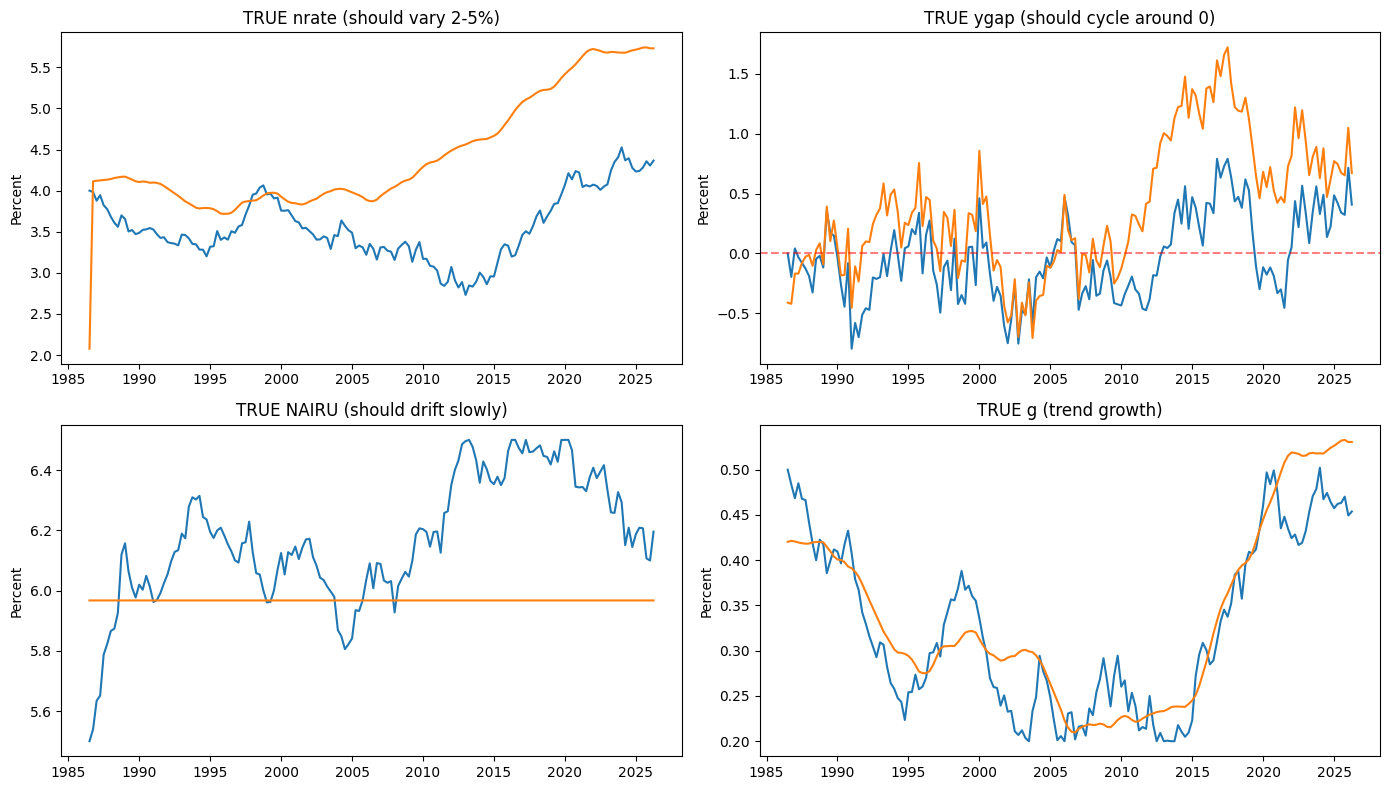

In [ ]:
# 1. Check parameter estimates
print("="*70)
print("PARAMETER ESTIMATES")
print("="*70)
for i, name in enumerate(model.param_names):
    print(f"{name:<15} {res.params[i]:>12.4f}")

# 2. Check if NAIRU exists in output
print("\n" + "="*70)
print("SMOOTHED STATE SUMMARY")
print("="*70)
print(smoothed.describe())

# 3. Compare true vs estimated for key states
print("\n" + "="*70)
print("TRUE vs ESTIMATED (means)")
print("="*70)
print(f"{'State':<15} {'True Mean':>12} {'Est Mean':>12} {'Difference':>12}")
print("-"*70)
print(f"{'nrate':<15} {true_states['nrate_true'].mean():>12.3f} {smoothed['nrate'].mean():>12.3f} {smoothed['nrate'].mean()-true_states['nrate_true'].mean():>12.3f}")
print(f"{'ygap':<15} {true_states['ygap_true'].mean():>12.3f} {smoothed['ygap'].mean():>12.3f} {smoothed['ygap'].mean()-true_states['ygap_true'].mean():>12.3f}")
print(f"{'NAIRU':<15} {true_states['nairu_true'].mean():>12.3f} {smoothed['NAIRU'].mean():>12.3f} {smoothed['NAIRU'].mean()-true_states['nairu_true'].mean():>12.3f}")
print(f"{'g':<15} {true_states['g_true'].mean():>12.3f} {smoothed['g'].mean():>12.3f} {smoothed['g'].mean()-true_states['g_true'].mean():>12.3f}")

# 4. Check if ygap should be trending
print("\n" + "="*70)
print("YGAP ANALYSIS")
print("="*70)
print(f"True ygap:  min={true_states['ygap_true'].min():.3f}, max={true_states['ygap_true'].max():.3f}, std={true_states['ygap_true'].std():.3f}")
print(f"Est ygap:   min={smoothed['ygap'].min():.3f}, max={smoothed['ygap'].max():.3f}, std={smoothed['ygap'].std():.3f}")
print(f"True ygap should fluctuate around zero, not trend upward!")

# 5. Plot TRUE values to see if data generation is correct
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(true_states['nrate_true'])
axes[0,0].plot(smoothed["nrate"])
axes[0,0].set_title('TRUE nrate (should vary 2-5%)')
axes[0,0].set_ylabel('Percent')

axes[0,1].plot(true_states['ygap_true'])
axes[0,1].plot(smoothed["ygap"])

axes[0,1].set_title('TRUE ygap (should cycle around 0)')
axes[0,1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0,1].set_ylabel('Percent')

axes[1,0].plot(true_states['nairu_true'])
axes[1,0].plot(smoothed['NAIRU'])
axes[1,0].set_title('TRUE NAIRU (should drift slowly)')
axes[1,0].set_ylabel('Percent')

axes[1,1].plot(true_states['g_true'])
axes[1,1].plot(smoothed['g'])

axes[1,1].set_title('TRUE g (trend growth)')
axes[1,1].set_ylabel('Percent')

plt.tight_layout()
plt.show()

In [ ]:
"""
MARTIN Python (Option C) - Single-file modular implementation (template)
- All behavioural equations are translated structurally to Python
- Parameters are symbolic and stored in `PARAMS_TEMPLATE` (replace with real values or use estimator later)
- State-space connectors are placeholders (wrap your existing pistar/nairu/rstar classes)

Usage:
  - Drop this file into your project
  - Edit PARAMS_TEMPLATE with real C(...) values or leave placeholders
  - Provide observed data (pandas DataFrame) to state_spaces.run_all()
  - Run `python martin_python_full_model.py` to execute a baseline run with synthetic data

This is intended as a single-file package for convenience. For production split into modules as per README plan.
"""

import numpy as np
import pandas as pd
import json
from copy import deepcopy

# -----------------------------
# PARAMS TEMPLATE (symbolic)
# Fill with EViews C(...) values or use estimation mode later
# -----------------------------
PARAMS_TEMPLATE = {
    # example: RC equation coefficients
    "RC": {
        "c1": 0.0,
        "c2": 0.5,
        "c11": 0.1,
        "c31": 0.0,
        "c32": 0.0,
        "c50": 0.0
    },
    # Add placeholders for each equation referenced in MARTIN
    "NHFA": {"c1":0.0},
    "ID": {"c1":0.0},
    "PH": {"c1":0.0},
    "PTM": {"c1":0.0},
    "LE": {"c1":0.0},
    "LUR": {"c1":0.0},
    "PW": {"c1":0.0},
    "IBN": {"c1":0.0},
    "IBRE": {"c1":0.0},
    "GI": {"c1":0.0},
    "GC": {"c1":0.0},
    "XRE": {"c1":0.0},
    "XM": {"c1":0.0},
    "M": {"c1":0.0},
    # Add other blocks...
    "GLOBAL": {
        "pi_target": 2.5,
        "rcr_target": 2.5,
        "rstar_target": 2.5
    }
}

# -----------------------------
# Core: State container
# -----------------------------
class State:
    """A time-series state container with lag accessor.
    Stores variables as numpy arrays of length T.
    """
    def __init__(self, variables, T):
        self.T = T
        self.vars = {v: np.full(T, np.nan) for v in variables}
        self.variables = variables

    def set_series(self, name, series):
        arr = np.asarray(series)
        if arr.shape[0] != self.T:
            raise ValueError(f"Length mismatch for {name}: got {arr.shape[0]} expected {self.T}")
        self.vars[name] = arr.astype(float)


    def add_variable(self, name, initial=0.0):
        """
        Add a variable to the model state. If already present, do nothing.
        Creates a full time series of length T, initialized to `initial`.
        """
        if name not in self.vars:
            arr = np.full(self.T, initial, dtype=float)
            self.vars[name] = arr

    def get(self, name):
        return self.vars[name]

    def __getitem__(self, name):
        return self.vars[name]

    def __setitem__(self, name, val):
        arr = np.asarray(val)
        if arr.shape[0] != self.T:
            raise ValueError(f"Length mismatch when setting {name}")
        self.vars[name] = arr

    def initialize(self, init_dict):
        for k,v in init_dict.items():
            if k in self.vars:
                self.vars[k][0] = v

    def lag(self, name, k=1, t=None, default=np.nan):
        """Return value of variable `name` lagged k periods at time t.
        If t is None, returns full series shifted by k (useful for vector operations).
        """
        arr = self.vars[name]
        if t is None:
            res = np.concatenate((np.full(k, default), arr[:-k])) if k>0 else arr.copy()
            return res
        idx = t - k
        if idx < 0:
            return default
        return arr[idx]

    def to_dataframe(self):
        return pd.DataFrame(self.vars)

# -----------------------------
# Core: Params loader
# -----------------------------
class Params:
    def __init__(self, template=None):
        self.params = deepcopy(PARAMS_TEMPLATE) if template is None else deepcopy(template)

    def get(self, eqname, key, default=0.0):
        return self.params.get(eqname, {}).get(key, default)

    def set(self, eqname, key, value):
        if eqname not in self.params:
            self.params[eqname] = {}
        self.params[eqname][key] = value

    def to_json(self, path):
        with open(path,'w') as f:
            json.dump(self.params, f, indent=2)

    def from_json(self, path):
        with open(path,'r') as f:
            self.params = json.load(f)

# -----------------------------
# Blocks (structure-only) - each block implements update(state, t, params)
# The blocks below implement the logic and refer to params by name.
# -----------------------------

# Helper: safe log/diff
def dlog(x, prev):
    if prev==0 or np.isnan(prev):
        return 0.0
    return np.log(x) - np.log(prev)

# Trends block
def block_trends(state: State, t, params: Params):
    # tlla, tdlla
    if t==0:
        # initialize from existing or zero
        state.vars.setdefault('tlla', state.vars.get('tlla', np.full(state.T,0.0)))
        state.vars.setdefault('tdlla', state.vars.get('tdlla', np.full(state.T,0.0)))
    # tdlla = 0.95*tdlla(-1) + 0.05*aasteady_state_la
    prev_tdlla = state.lag('tdlla',1,t,0.0)
    aasteady = params.get('GLOBAL','aasteady_state_la',0.0)
    tdlla = 0.95 * prev_tdlla + 0.05 * aasteady
    state.vars['tdlla'][t] = tdlla
    # tlla = tlla(-1) + tdlla
    tlla_prev = state.lag('tlla',1,t,0.0)
    state.vars['tlla'][t] = tlla_prev + tdlla

    # trend hours tllhpp, tdllhpp
    prev_tdl = state.lag('tdllhpp',1,t,0.0)
    state.vars.setdefault('tdllhpp', np.full(state.T,0.0))
    state.vars.setdefault('tllhpp', np.full(state.T,0.0))
    tdllhpp = 0.95 * prev_tdl
    state.vars['tdllhpp'][t] = tdllhpp
    state.vars['tllhpp'][t] = state.lag('tllhpp',1,t,0.0) + tdllhpp

    # trend population
    prev_tdlpop = state.lag('tdllpop',1,t,0.0)
    aasteady_pop = params.get('GLOBAL','aasteady_state_pop',0.0)
    tdllpop = 0.975 * prev_tdlpop + 0.025 * aasteady_pop
    state.vars.setdefault('tdllpop', np.full(state.T,0.0))
    state.vars.setdefault('tllpop', np.full(state.T,0.0))
    state.vars['tdllpop'][t] = tdllpop
    state.vars['tllpop'][t] = state.lag('tllpop',1,t,0.0) + tdllpop

    # inflation expectations
    pi_e_prev = state.lag('pi_e',1,t,0.0)
    pi_target = params.get('GLOBAL','pi_target',2.5)
    state.vars.setdefault('pi_e', np.full(state.T,pi_target))
    state.vars['pi_e'][t] = 0.9 * pi_e_prev + 0.1 * pi_target

    # potential growth TY_POT = TDLLA + TDLLPOP + TDLLHPP
    state.vars.setdefault('TY_POT', np.full(state.T,0.0))
    tlla_val = state.vars['tdlla'][t]
    tdllpop_val = state.vars['tdllpop'][t]
    tdllhpp_val = state.vars['tdllhpp'][t]
    state.vars['TY_POT'][t] = tlla_val + tdllpop_val + tdllhpp_val

# Household block (selected equations & identities)
def block_households(state: State, t, params: Params):
    # hoy = nhoy / pc
    pc = state.lag('pc',0,t,1.0)
    nhoy = state.lag('nhoy',0,t,0.0)
    state.vars.setdefault('hoy', np.full(state.T, np.nan))
    state.vars['hoy'][t] = nhoy / pc if pc!=0 else 0.0

    # nominal household disposable income nhdy = nhcoe + nhoy
    nhcoe = state.lag('nhcoe',0,t,0.0)
    state.vars.setdefault('nhdy', np.full(state.T, np.nan))
    state.vars['nhdy'][t] = nhcoe + nhoy

    # real disposable income hdy = nhdy / pc
    state.vars.setdefault('hdy', np.full(state.T, np.nan))
    state.vars['hdy'][t] = state.vars['nhdy'][t] / pc if pc!=0 else 0.0

    # nominal household saving nhs = nhdy - nc - kidc
    nc = state.lag('nc',0,t,0.0)
    kidc = state.lag('kidc',0,t,0.0)
    state.vars.setdefault('nhs', np.full(state.T, np.nan))
    state.vars['nhs'][t] = state.vars['nhdy'][t] - nc - kidc

    # saving ratio nhsr = nhs / (nhdy - kidc)
    denom = state.vars['nhdy'][t] - kidc
    state.vars.setdefault('nhsr', np.full(state.T, np.nan))
    state.vars['nhsr'][t] = state.vars['nhs'][t] / denom if denom!=0 else 0.0

    # financial assets nha = nhnfa + nhfa
    state.vars.setdefault('nha', np.full(state.T, np.nan))
    state.vars['nha'][t] = state.lag('nhnfa',0,t,0.0) + state.lag('nhfa',0,t,0.0)

    # net worth nhnw = nha - nhl ; hnw = nhnw / pc
    nhl = state.lag('nhl',0,t,0.0)
    state.vars.setdefault('nhnw', np.full(state.T, np.nan))
    state.vars['nhnw'][t] = state.vars['nha'][t] - nhl
    state.vars.setdefault('hnw', np.full(state.T, np.nan))
    state.vars['hnw'][t] = state.vars['nhnw'][t] / pc if pc!=0 else 0.0

    # nominal household consumption nc = pc * rc / 100 (identity in EViews)
    state.vars.setdefault('rc', np.full(state.T,0.0))
    state.vars.setdefault('nc', np.full(state.T,0.0))
    state.vars['nc'][t] = pc * state.lag('rc',0,t,0.0) / 100.0

    # consumption of fixed capital KIDC: d(log(kidc)) = 0.95*d(log(kidc(-1))) + (1-0.95)*(tdlla(-1)+...)
    prev_kidc = state.lag('kidc',1,t,1.0)
    prev_kidc2 = state.lag('kidc',2,t, prev_kidc)
    tdlla_1 = state.lag('tdlla',1,t,0.0)
    tdllpop_1 = state.lag('tdllpop',1,t,0.0)
    tdllhpp_1 = state.lag('tdllhpp',1,t,0.0)
    pi_e_val = state.lag('pi_e',0,t, params.get('GLOBAL','pi_target',2.5))
    dlog_kidc = 0.95 * dlog(prev_kidc, prev_kidc2) + (1 - 0.95) * (tdlla_1 + tdllpop_1 + tdllhpp_1 + pi_e_val/400.0)
    state.vars['kidc'][t] = prev_kidc * np.exp(dlog_kidc)

# Housing block (selected)
def block_housing(state: State, t, params: Params):
    # Dwelling investment - log-diff eqn approx: D(LOG(ID)) = ...
    prev_id = state.lag('id',1,t,1.0)
    prev_id4 = state.lag('id',4,t,prev_id)
    rc_prev = state.lag('rc',1,t,0.0)
    # Placeholder simple dynamic: id growth reacts to previous gap and trends
    state.vars.setdefault('id', np.full(state.T, 1.0))
    growth = params.get('ID','c1',0.0) - 0.1*(np.log(prev_id) - np.log(state.lag('rc',1,t,1.0))) + state.lag('tdllpop',1,t,0.0) + state.lag('tdllhpp',1,t,0.0) + state.lag('tdlla',1,t,0.0)
    state.vars['id'][t] = prev_id * np.exp(growth)

    # housing prices PH: simplified AR process on log(PH)
    state.vars.setdefault('ph', np.full(state.T,1.0))
    ph_prev = state.lag('ph',1,t,1.0)
    ph_prev4 = state.lag('ph',4,t, ph_prev)
    rho = params.get('PH','c4',0.5)
    state.vars['ph'][t] = ph_prev * np.exp(rho * (np.log(ph_prev) - np.log(state.lag('prt',1,t,1.0))))

# Business investment (selected)
def block_business(state: State, t, params: Params):
    # Non-mining Investment IBN simplified
    state.vars.setdefault('ibn', np.full(state.T,1.0))
    ibn_prev = state.lag('ibn',1,t,1.0)
    # investment growth depends on past gap and cost of capital
    rbr = state.lag('rbr',1,t,1.0)
    tdlla_1 = state.lag('tdlla',1,t,0.0)
    growth_ibn = params.get('IBN','c2',0.0) - 0.05*(np.log(ibn_prev) - np.log(state.lag('gne',1,t,1.0))) + tdlla_1
    state.vars['ibn'][t] = ibn_prev * np.exp(growth_ibn)

    # Mining investment
    state.vars.setdefault('ibre', np.full(state.T,1.0))
    state.vars['ibre'][t] = state.lag('ibre',1,t,1.0)

    # total private business investment
    state.vars.setdefault('ib', np.full(state.T,1.0))
    state.vars['ib'][t] = state.vars['ibn'][t] + state.vars['ibre'][t]

# Public sector
def block_public(state: State, t, params: Params):
    state.vars.setdefault('gi', np.full(state.T,0.5))
    state.vars.setdefault('gc', np.full(state.T,0.5))
    state.vars['gi'][t] = state.lag('gi',1,t,0.5)
    state.vars['gc'][t] = state.lag('gc',1,t,0.5)
    state.vars.setdefault('g', np.full(state.T,0.0))
    state.vars['g'][t] = state.vars['gi'][t] + state.vars['gc'][t]

# Trade block
def block_trade(state: State, t, params: Params):
    state.vars.setdefault('xm', np.full(state.T,1.0))
    state.vars.setdefault('xre', np.full(state.T,1.0))
    state.vars.setdefault('x', np.full(state.T,1.0))
    state.vars['xm'][t] = state.lag('xm',1,t,1.0)
    state.vars['xre'][t] = state.lag('xre',1,t,1.0)
    state.vars['x'][t] = state.vars['xm'][t] + state.vars['xre'][t]

    # imports
    state.vars.setdefault('m', np.full(state.T,1.0))
    state.vars['m'][t] = state.lag('m',1,t,1.0)

# National accounts
def block_national_accounts(state: State, t, params: Params):
    # Domestic final demand dfd = rc + id + ib + g + otc - ats
    rc = state.lag('rc',0,t,0.0)
    id_ = state.lag('id',0,t,0.0)
    ib = state.lag('ib',0,t,0.0)
    g = state.lag('g',0,t,0.0)
    otc = state.lag('otc',0,t,0.0)
    ats = state.lag('ats',0,t,0.0)
    v = state.lag('v',0,t,0.0)
    x = state.lag('x',0,t,0.0)
    m = state.lag('m',0,t,0.0)
    sd = state.lag('sd',0,t,0.0)
    state.vars.setdefault('dfd', np.full(state.T,0.0))
    state.vars['dfd'][t] = rc + id_ + ib + g + otc - ats
    state.vars.setdefault('y', np.full(state.T,0.0))
    state.vars['y'][t] = rc + id_ + ib + g + otc - ats + v + x - m + sd

# Prices and wages
def block_prices_wages(state: State, t, params: Params):
    # Trimmed mean inflation PTM: simplified Phillips form
    state.vars.setdefault('ptm', np.full(state.T,1.0))
    ptm_prev = state.lag('ptm',1,t,1.0)
    pi_e = state.lag('pi_e',0,t,params.get('GLOBAL','pi_target',2.5))
    # simple AR(1) + expected inflation anchor
    theta = params.get('PTM','c4',0.5)
    state.vars['ptm'][t] = ptm_prev * np.exp((1-theta)*pi_e/400.0 + theta * dlog(ptm_prev, state.lag('ptm',2,t,ptm_prev)))

    # CPI P: linked to PTM and oil
    state.vars.setdefault('p', np.full(state.T,1.0))
    p_prev = state.lag('p',1,t,1.0)
    state.vars['p'][t] = p_prev * np.exp(dlog(state.vars['ptm'][t], ptm_prev))

# Labour market
def block_labour(state: State, t, params: Params):
    # Employment LE: simplified dynamic
    state.vars.setdefault('le', np.full(state.T,1.0))
    state.vars['le'][t] = state.lag('le',1,t,1.0) * (1 + 0.01 * (state.lag('y',0,t,1.0) - state.lag('ty_pot',0,t,0.0)))

    # Unemployment rate LUR: simple Okun style
    state.vars.setdefault('lur', np.full(state.T,5.0))
    if t==0:
        state.vars['lur'][t] = state.lag('tlur',0,t,5.0)
    else:
        state.vars['lur'][t] = state.vars['lur'][t-1] - 0.4 * (state.vars['y'][t] - state.lag('ty_pot',0,t,0.0))

    # TLUR (NAIRU) is expected to be supplied by state-space module; if not present default to lag
    state.vars.setdefault('tlur', np.full(state.T,5.0))
    state.vars['tlur'][t] = state.lag('tlur',1,t, state.vars['tlur'][0])

    # unemployment gap
    state.vars.setdefault('lurgap', np.full(state.T,0.0))
    state.vars['lurgap'][t] = state.vars['lur'][t] - state.vars['tlur'][t]

# Interest and exchange rates
def block_interest_rates(state: State, t, params: Params):
    # Nominal cash rate ncr via policy rule
    state.vars.setdefault('ncr', np.full(state.T, params.get('GLOBAL','rstar_target',2.5)))
    if t==0:
        state.vars['ncr'][t] = params.get('GLOBAL','rstar_target',2.5)
    else:
        # simplifed TR: ncr = 0.7*ncr(-1) + 0.3*(rstar + inflation + ...) - adjustments
        prev = state.lag('ncr',1,t, params.get('GLOBAL','rstar_target',2.5))
        rstar = state.lag('rstar',0,t, params.get('GLOBAL','rstar_target',2.5))
        inflation = 100*(state.vars['ptm'][t]/state.lag('ptm',4,t,1.0)-1) if t>=4 else 0.0
        tr_ptm = params.get('GLOBAL','tr_ptm',1.0)
        tr_lurgap = params.get('GLOBAL','tr_lurgap',0.0)
        tr_dlur = params.get('GLOBAL','tr_dlur',0.0)
        # policy target
        pol_target = rstar + inflation + (tr_ptm - 1)*(inflation - params.get('GLOBAL','pi_target',2.5)) - tr_lurgap*state.vars['lurgap'][t]
        new = 0.7*prev + 0.3*pol_target - tr_dlur/2.0*(state.vars['lur'][t] - state.lag('lur',2,t, state.vars['lur'][t]))
        state.vars['ncr'][t] = max(new, 0.1)

    # real cash rate rcr
    state.vars.setdefault('rcr', np.full(state.T,0.0))
    ptm_curr = state.vars['ptm'][t]
    ptm_lag4 = state.lag('ptm',4,t,ptm_curr)
    inflation_rate = (ptm_curr/ptm_lag4 - 1) if ptm_lag4!=0 else 0.0
    state.vars['rcr'][t] = ((1+state.vars['ncr'][t]/100.0)/(1+inflation_rate))*100.0 - 100.0

# World block (selected)
def block_world(state: State, t, params: Params):
    # major trading partner growth
    state.vars.setdefault('wy', np.full(state.T,0.0))
    if t==0:
        state.vars['wy'][t] = state.lag('wy',0,t,0.0)
    else:
        state.vars['wy'][t] = state.lag('wy',1,t,0.0) * (1 + 0.9*(state.lag('wy',1,t,0.0) - state.lag('wy',2,t,0.0)))

# State-space connectors (placeholders; wrap existing classes)
def run_state_space_modules(obs_df):
    # obs_df: pandas DataFrame of observed variables
    # Placeholder: create synthetic pistar, nairu, rstar series from obs_df index length
    T = len(obs_df)
    pistar = np.linspace(2.0,2.5,T)
    nairu = np.linspace(5.5,4.5,T)
    rstar = np.linspace(1.5,1.0,T)
    return pistar, nairu, rstar

# -----------------------------
# Solver: orchestrate block updates per period with inner iterations for simultaneous equations
# -----------------------------
class Solver:
    def __init__(self, state: State, params: Params, blocks=None, max_iter=10, tol=1e-6):
        self.state = state
        self.params = params
        self.blocks = blocks if blocks is not None else []
        self.max_iter = max_iter
        self.tol = tol

    def run(self):
        T = self.state.T
        for t in range(T):
            # inner iteration to handle simultaneity at time t
            prev_snapshot = {v: self.state.vars[v][t] for v in self.state.variables}
            for it in range(self.max_iter):
                for block in self.blocks:
                    block(self.state, t, self.params)
                # check convergence
                diffs = [abs(self.state.vars[v][t] - prev_snapshot.get(v, np.nan)) for v in self.state.variables]
                maxdiff = np.nanmax(diffs)
                prev_snapshot = {v: self.state.vars[v][t] for v in self.state.variables}
                if maxdiff < self.tol:
                    break
        return self.state

# -----------------------------
# Build variables list from EViews code (representative set)
# -----------------------------
ALL_VARIABLES = [
    # trends
    'tlla','tdlla','tllhpp','tdllhpp','tllpop','tdllpop','pi_e','TY_POT',
    # households
    'hoy','nhoy','nhcoe','nhdy','hdy','nhs','kidc','nhsr','nhnfa','nhfa','nha','nhnw','hnw','rc','nc',
    # housing
    'id','ph','prt','iddr','kid','iddr','kibn','kibre','ibre','ibn','ib',
    # public
    'gi','gc','g',
    # trade
    'xm','xre','x','m',
    # national accounts
    'dfd','y','v','sd','ats',
    # prices & wages
    'ptm','p','pae','pw','pc','pid','pibn','pibre','px','pm','pmcg',
    # labour
    'le','lur','tlur','lurgap','lf','lpop','lpr','ty_pot',
    # interest
    'ncr','rcr','n2r','n10r','nmr','rbr','rcr_target','rstar','pistar',
    # world
    'wy','wp','wpoil','wr2r','wr2sp','rtwi','ntwi','nusd'
]

# -----------------------------
# Baseline runner with synthetic data
# -----------------------------
T = 160
params = Params()

# prepare state and populate with initial series or zeros
state = State(ALL_VARIABLES, T)

# create synthetic observed df to feed state-space wrappers (dates)
dates = pd.period_range('1986Q3', periods=T, freq='Q')
obs_df = pd.DataFrame(index=dates)

# run state-space modules to get pistar, nairu, rstar
pistar, nairu, rstar = run_state_space_modules(obs_df)

# set into state
state.set_series('pistar', pistar)
state.set_series('tlur', nairu)  # tlur is NAIRU in EViews naming
state.set_series('rstar', rstar)

# initialize some baselines
state.set_series('ptm', np.ones(T))
state.set_series('pc', np.ones(T))
state.set_series('nhcoe', np.ones(T)*100.0)
state.set_series('nhoy', np.ones(T)*10.0)
state.set_series('kidc', np.ones(T)*5.0)
state.set_series('id', np.ones(T)*2.0)
state.set_series('ibn', np.ones(T)*3.0)
state.set_series('ibre', np.ones(T)*1.0)
state.set_series('gi', np.ones(T)*1.0)
state.set_series('gc', np.ones(T)*1.0)
state.set_series('x', np.ones(T)*5.0)
state.set_series('m', np.ones(T)*4.0)
state.set_series('ots', np.zeros(T))
state.set_series('rc', np.ones(T)*50.0)
state.set_series('pdummy', np.ones(T))

# create block list in logical order
blocks = [block_trends, block_households, block_housing, block_business, block_public, block_trade, block_national_accounts, block_prices_wages, block_labour, block_interest_rates, block_world]

ALL_VARIABLES = ['tlla','tdlla','tllhpp','tdllhpp','lhpp','tllpop','tdllpop','pi_e','v', 'sd', 'ty_pot',
 'TY_POT','rc','nhoy','hoy','nhdy','hdy','nhs','nhsr', 'nhl', 'nc', 'nhnfa', 'nhfa', 'prt', 'rbr' , 'gne', 'otc', 'ats']

for v in ALL_VARIABLES:
    state.add_variable(v, 0.0)

solver = Solver(state, params, blocks=blocks, max_iter=5, tol=1e-5)
result_state = solver.run()

df = result_state.to_dataframe()
print(df[['pistar','tlur','rstar']].head())
print('\n--- Sample outputs (y, ptm, ncr) ---')
print(df[['y','ptm','ncr']].head())


In [ ]:
T = 160
params = Params()

# prepare state and populate with initial series or zeros
state = State(ALL_VARIABLES, T)

# create synthetic observed df to feed state-space wrappers (dates)
dates = pd.period_range('1986Q3', periods=T, freq='Q')
obs_df = pd.DataFrame(index=dates)

# run state-space modules to get pistar, nairu, rstar
pistar, nairu, rstar = run_state_space_modules(obs_df)

# set into state
state.set_series('pistar', pistar)
state.set_series('tlur', nairu)  # tlur is NAIRU in EViews naming
state.set_series('rstar', rstar)

# initialize some baselines
state.set_series('ptm', np.ones(T))
state.set_series('pc', np.ones(T))
state.set_series('nhcoe', np.ones(T)*100.0)
state.set_series('nhoy', np.ones(T)*10.0)
state.set_series('kidc', np.ones(T)*5.0)
state.set_series('id', np.ones(T)*2.0)
state.set_series('ibn', np.ones(T)*3.0)
state.set_series('ibre', np.ones(T)*1.0)
state.set_series('gi', np.ones(T)*1.0)
state.set_series('gc', np.ones(T)*1.0)
state.set_series('x', np.ones(T)*5.0)
state.set_series('m', np.ones(T)*4.0)
state.set_series('ots', np.zeros(T))
state.set_series('rc', np.ones(T)*50.0)
state.set_series('pdummy', np.ones(T))

# create block list in logical order
blocks = [block_trends, block_households, block_housing, block_business, block_public, block_trade, block_national_accounts, block_prices_wages, block_labour, block_interest_rates, block_world]

ALL_VARIABLES = ['tlla','tdlla','tllhpp','tdllhpp','lhpp','tllpop','tdllpop','pi_e','v', 'sd', 'ty_pot',
 'TY_POT','rc','nhoy','hoy','nhdy','hdy','nhs','nhsr', 'nhl', 'nc', 'nhnfa', 'nhfa', 'prt', 'rbr' , 'gne', 'otc', 'ats']

for v in ALL_VARIABLES:
    state.add_variable(v, 0.0)

solver = Solver(state, params, blocks=blocks, max_iter=5, tol=1e-5)
result_state = solver.run()

df = result_state.to_dataframe()
print(df[['pistar','tlur','rstar']].head())
print('\n--- Sample outputs (y, ptm, ncr) ---')
print(df[['y','ptm','ncr']].head())


     pistar  tlur     rstar
0  2.000000   5.5  1.500000
1  2.003145   5.5  1.496855
2  2.006289   5.5  1.493711
3  2.009434   5.5  1.490566
4  2.012579   5.5  1.487421

--- Sample outputs (y, ptm, ncr) ---
    y       ptm  ncr
0 NaN  1.000313  2.5
1 NaN  1.000907  NaN
2 NaN  1.002052  NaN
3 NaN  1.003703  NaN
4 NaN  1.005816  NaN
